In [ ]:
#Imports

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os


from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from google.colab import files
from gensim.models import KeyedVectors

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [ ]:
# Checking the files in the input directory

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/claytonmiranda/en-fr-20k/en-fr-20k.csv
/kaggle/input/datasets/claytonmiranda/en-fr-1m/en-fr-1m.csv
/kaggle/input/datasets/yekenot/fasttext-crawl-300d-2m/crawl-300d-2M.vec


In [ ]:
# DataFrame

df = pd.read_csv('/kaggle/input/datasets/claytonmiranda/en-fr-1m/en-fr-1m.csv', nrows=100000)

df.columns = ["en", "fr"]

df = df.dropna()

In [ ]:
# DataFrame - Info

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99998 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   en      99998 non-null  object
 1   fr      99998 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


In [ ]:
# Display the first few rows of the DataFrame

df.head(10)

,en,fr
0,Changing Lives | Changing Society | How It Wor...,Il a transformé notre vie | Il a transformé la...
1,Site map,Plan du site
2,Feedback,Rétroaction
3,Credits,Crédits
4,Français,English
5,What is light ?,Qu’est-ce que la lumière?
6,The white light spectrum Codes in the light Th...,La découverte du spectre de la lumière blanche...
7,The sky of the first inhabitants A contemporar...,Le ciel des premiers habitants La vision conte...
8,Cartoon,Bande dessinée
9,Links,Liens


In [7]:
# Clean DataFrame

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", "", text)
    return text

df["en"] = df["en"].apply(clean_text)
df["fr"] = df["fr"].apply(clean_text)

In [8]:
# Vocabulary

def build_vocab(sentences, min_freq=2):
    counter = Counter()

    for sent in sentences:
        counter.update(sent.split())

    vocab = {"<pad>":0, "<sos>":1, "<eos>":2, "<unk>":3}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

eng_vocab = build_vocab(df["en"])
fr_vocab = build_vocab(df["fr"])

inv_fr_vocab = {v:k for k,v in fr_vocab.items()}

In [9]:
# English Vocabulary

for i, (w, n) in enumerate(eng_vocab.items()):
    if i == 10:
        break
    print(f'Palavra {n}: {w}')

print(f'Quatidade de Palavras: {len(eng_vocab.keys())}')

Palavra 0: <pad>
Palavra 1: <sos>
Palavra 2: <eos>
Palavra 3: <unk>
Palavra 4: changing
Palavra 5: lives
Palavra 6: society
Palavra 7: how
Palavra 8: it
Palavra 9: works
Quatidade de Palavras: 27980


In [10]:
# Franch Vocabulary

for i, (w, n) in enumerate(fr_vocab.items()):
    if i == 10:
        break
    print(f'Palavra {n}: {w}')

print(f'Quatidade de Palavras: {len(fr_vocab.keys())}')

Palavra 0: <pad>
Palavra 1: <sos>
Palavra 2: <eos>
Palavra 3: <unk>
Palavra 4: il
Palavra 5: a
Palavra 6: transformé
Palavra 7: notre
Palavra 8: vie
Palavra 9: la
Quatidade de Palavras: 35373


In [ ]:
# Converting the vocabularies to tensors

class TranslationDataset(Dataset):
    def __init__(self, df):
        self.en = df["en"].values
        self.fr = df["fr"].values

    def encode(self, sentence, vocab):
        tokens = sentence.split()
        return [vocab.get(word, vocab["<unk>"]) for word in tokens]

    def __len__(self):
        return len(self.en)

    def __getitem__(self, idx):
        src = [eng_vocab["<sos>"]] + self.encode(self.en[idx], eng_vocab) + [eng_vocab["<eos>"]]
        trg = [fr_vocab["<sos>"]] + self.encode(self.fr[idx], fr_vocab) + [fr_vocab["<eos>"]]

        return torch.tensor(src), torch.tensor(trg)

In [ ]:
# Padding sequences

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)

    src_pad = pad_sequence(src_batch, padding_value=eng_vocab["<pad>"])
    trg_pad = pad_sequence(trg_batch, padding_value=fr_vocab["<pad>"])

    return src_pad, trg_pad

In [ ]:
# Train/Val Split

train_df, val_df = train_test_split(df, test_size=0.1)

train_data = TranslationDataset(train_df)
val_data = TranslationDataset(val_df)

train_loader = DataLoader(
    train_data,
    batch_size=16,            
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,              
    pin_memory=True        
)

val_loader = DataLoader(
    val_data,
    batch_size=16,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Embedding Matrix

w2v = KeyedVectors.load_word2vec_format(
    "/kaggle/input/datasets/yekenot/fasttext-crawl-300d-2m/crawl-300d-2M.vec"
)

EMB_DIM = 300 

embedding_matrix = np.zeros((len(eng_vocab), EMB_DIM))

for word, i in eng_vocab.items():
    try:
        embedding_matrix[i] = w2v[word]
    except KeyError:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMB_DIM,))

In [ ]:
# Encoder

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, embedding_matrix, dropout, n_layers=2):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=False, 
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=n_layers, dropout=dropout)

    def forward(self, src):
        
        embedded = self.embedding(src)
        
        embedded = self.dropout(embedded)
        
        outputs, hidden = self.rnn(embedded)
        
        return hidden

In [ ]:
# Decoder

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, n_layers=2):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)

        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=n_layers, dropout=dropout)
        
        self.fc = nn.Linear(hid_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(0))

        return prediction, hidden

In [ ]:
# Seq2Seq

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device 

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        
        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim 

        # Making sure outputs is on the same device as the input data 

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(src.device)

        # hidden [n_layers, batch_size, hid_dim]
        hidden = self.encoder(src)

        # <sos> is the first input to the decoder
        input = trg[0,:]

        for t in range(1, trg_len):
            # Decoder receives the input and the accumulated hidden state
            output, hidden = self.decoder(input, hidden)
            
            # Salve the prediction
            outputs[t] = output

            # Teacher Forcing
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            
            # Maximum probability word
            top1 = output.argmax(1)

            # Define the next input
            input = trg[t] if teacher_force else top1

        return outputs

In [ ]:
# Hyperparameters

INPUT_DIM = len(eng_vocab)
OUTPUT_DIM = len(fr_vocab)
EMB_DIM = 300     
HID_DIM = 512     
DROPOUT = 0.5      
N_LAYERS = 2       

# Encoder | Decoder | Seq2Seq

enc = Encoder(INPUT_DIM, EMB_DIM, HID_DIM, embedding_matrix, DROPOUT, N_LAYERS)
dec = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, DROPOUT, N_LAYERS)
model = Seq2Seq(enc, dec, device).to(device)

# Counting Kaggle GPUs

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

🚀 Usando 2 GPUs!


In [ ]:
# Loss Function and Optimizer

criterion = nn.CrossEntropyLoss(ignore_index=fr_vocab["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training function

def train(model, loader):
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output = output[1:].reshape(-1, output.shape[-1])
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
# Validation function

def val(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0) 

            output = output[1:].reshape(-1, output.shape[-1])
            trg = trg[1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
# Training Loop with Early Stopping

NUM_EPOCHS = 30
PATIENCE = 3

train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):

    train_loss = train(model, train_loader)
    val_loss = val(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 30)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Salving the model
        torch.save(model.state_dict(), "best_model.pt")

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print("Early stopping!")
        break

Epoch 1
Train Loss: 6.1069
Val Loss:   6.1042
------------------------------
Epoch 2
Train Loss: 5.2943
Val Loss:   5.9508
------------------------------
Epoch 3
Train Loss: 4.9908
Val Loss:   5.8672
------------------------------
Epoch 4
Train Loss: 4.7937
Val Loss:   5.8153
------------------------------
Epoch 5
Train Loss: 4.6536
Val Loss:   5.8105
------------------------------
Epoch 6
Train Loss: 4.5441
Val Loss:   5.7877
------------------------------
Epoch 7
Train Loss: 4.4569
Val Loss:   5.8105
------------------------------
Epoch 8
Train Loss: 4.3818
Val Loss:   5.7917
------------------------------
Epoch 9
Train Loss: 4.3213
Val Loss:   5.8095
------------------------------
🛑 Early stopping ativado!


In [ ]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
# Salving the model weights

if isinstance(model, torch.nn.DataParallel):
    torch.save(model.module.state_dict(), 'model_weights.pt')
else:
    torch.save(model.state_dict(), 'model_weights.pt')

# Salving the vocabularies

vocab_data = {
    'eng_vocab': eng_vocab,
    'fr_vocab': fr_vocab,
    'idx_to_word_en': {v: k for k, v in eng_vocab.items()},
    'idx_to_word_fr': {v: k for k, v in fr_vocab.items()}
}

torch.save(vocab_data, 'vocabs.pt')

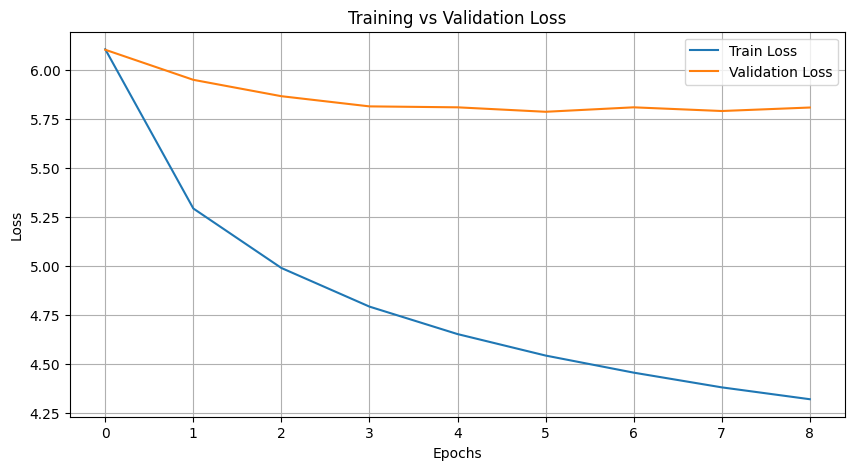

In [ ]:
# Plotting Loss Curves (Val | Train)

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Recriando os dicionários inversos (IDs para Palavras)

idx_to_word_en = {v: k for k, v in eng_vocab.items()}
idx_to_word_fr = {v: k for k, v in fr_vocab.items()}

In [ ]:
# Translation function

def translate(sentence, max_len=20):
    model.eval()

    # 1. Text to Indexes
    tokens = sentence.lower().split()
    tokens = ["<sos>"] + tokens + ["<eos>"]
    src_indexes = [eng_vocab.get(t, eng_vocab["<unk>"]) for t in tokens]
    
    # 2. Tensor and send to GPU
    src_tensor = torch.tensor(src_indexes).unsqueeze(1).to(device)

    # 3. 'hidden' inicial
    with torch.no_grad():
        if isinstance(model, nn.DataParallel):
            hidden = model.module.encoder(src_tensor)
        else:
            hidden = model.encoder(src_tensor)

    trg_indexes = [fr_vocab["<sos>"]]

    # 4. Translation loop
    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]]).to(device)

        # Decoder step
        with torch.no_grad():
            if isinstance(model, nn.DataParallel):
                output, hidden = model.module.decoder(trg_tensor, hidden)
            else:
                output, hidden = model.decoder(trg_tensor, hidden)

        pred = output.argmax(1).item()
        trg_indexes.append(pred)

        if pred == fr_vocab["<eos>"]:
            break

    # 5. Indexes to Text
    return " ".join([
        idx_to_word_fr[i] 
        for i in trg_indexes 
        if i not in [fr_vocab["<sos>"], fr_vocab["<eos>"], fr_vocab["<pad>"]]
    ])

In [ ]:
# Translating a sentence

english_sentence = [
    ["i", "am", "very", "happy", "today"],
    ["the", "sky", "is", "very", "blue"],
    ["hello", "how", "are", "you", "today"],
    ["the", "sun", "is", "very", "bright"],
    ["this", "is", "a", "very", "good", "day"],
    ["the", "sea", "is", "very", "calm"]
]
french_translation = []

for sentence in english_sentence:
    sentence_str = " ".join(sentence)
    translation = translate(sentence_str)
    french_translation.append(translation.split()) 

In [ ]:
# Bleu Score

french_reference = [
    ["je", "suis", "très", "heureux", "aujourdhui"],
    ["le", "ciel", "est", "très", "bleu"],
    ["bonjour", "comment", "ça", "va", "aujourdhui"],
    ["le", "soleil", "est", "très", "brillant"],
    ["cest", "une", "très", "bonne", "journée"],
    ["la", "mer", "est", "très", "calme"]
]
smooth = SmoothingFunction().method1
scores = []

for ref, pred in zip(french_reference, french_translation):
    score = sentence_bleu([ref], pred, smoothing_function=smooth)
    scores.append(score)

print(sum(scores) / len(scores))